<a href="https://colab.research.google.com/github/adfaihsan/TugasAkhir/blob/main/03_Analisis_Evaluasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Analisis Hasil & Evaluasi
**Platform**: Google Colab | **Proyek**: Tugas Akhir — Klasifikasi Tumor Otak MRI

Notebook ini berisi semua analisis setelah training model selesai.

**Bagian:**
- **A. Setup** — Mount Drive, load model, siapkan data generator
- **B. Perbandingan 10 Versi** — Grafik akurasi, F1 heatmap, efisiensi
- **C. Evaluasi Model Terbaik (V7)** — Classification report, confusion matrix, benchmark
- **D. Explainable AI** — Score-CAM visualization
- **E. Analisis Tambahan** — Efisiensi komputasi, baseline metrics, info hardware

> **Prasyarat**: Semua 10 versi training sudah selesai dan file `summary_V1.csv` s/d `summary_V10.csv` sudah di-upload ke Google Drive.

## Bagian A: Setup

In [ ]:
"""
=============================================================================
CELL 1: MOUNT GOOGLE DRIVE & PROJECT SETUP
=============================================================================
"""

import os
import json

# ---------------------------------------------------------------------------
# 1. MOUNT GOOGLE DRIVE
# ---------------------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

# ---------------------------------------------------------------------------
# 2. DEFINISIKAN PATH UTAMA
# ---------------------------------------------------------------------------
BASE_PATH = '/content/drive/MyDrive/TugasAkhir'
DATASET_PATH = os.path.join(BASE_PATH, 'Dataset')
PREPROCESSED_PATH = os.path.join(DATASET_PATH, 'Preprocessing')
MODELS_PATH = os.path.join(BASE_PATH, 'Saved_Models')
RESULTS_PATH = os.path.join(BASE_PATH, 'Results')
VIS_PATH = os.path.join(BASE_PATH, 'Visualizations')

# Buat folder jika belum ada
for p in [RESULTS_PATH, VIS_PATH]:
    os.makedirs(p, exist_ok=True)

# ---------------------------------------------------------------------------
# 3. LOAD KONFIGURASI PROJECT
# ---------------------------------------------------------------------------
config_file = os.path.join(BASE_PATH, 'project_config.json')
if os.path.exists(config_file):
    with open(config_file, 'r') as f:
        config = json.load(f)
    print("Konfigurasi project dimuat dari:", config_file)
else:
    print("WARNING: project_config.json tidak ditemukan. Menggunakan path default.")

print("\n" + "=" * 70)
print("SETUP SELESAI")
print("=" * 70)
print(f"  Base Path         : {BASE_PATH}")
print(f"  Dataset Preprocessed: {PREPROCESSED_PATH}")
print(f"  Models Path       : {MODELS_PATH}")
print(f"  Results Path      : {RESULTS_PATH}")
print(f"  Visualizations    : {VIS_PATH}")

# Cek ketersediaan model
print("\nModel yang tersedia di Drive:")
if os.path.exists(MODELS_PATH):
    for f in sorted(os.listdir(MODELS_PATH)):
        if f.endswith('.keras'):
            size_mb = os.path.getsize(os.path.join(MODELS_PATH, f)) / (1024*1024)
            print(f"  [+] {f} ({size_mb:.1f} MB)")
else:
    print("  WARNING: Folder Saved_Models tidak ditemukan!")

# Cek ketersediaan CSV hasil
print("\nCSV hasil yang tersedia:")
if os.path.exists(RESULTS_PATH):
    csvs = [f for f in sorted(os.listdir(RESULTS_PATH)) if f.endswith('.csv')]
    for f in csvs:
        print(f"  [+] {f}")
    print(f"  Total: {len(csvs)} file CSV")
else:
    print("  WARNING: Folder Results tidak ditemukan!")


Mounted at /content/drive
Konfigurasi project dimuat dari: /content/drive/MyDrive/TugasAkhir/project_config.json

SETUP SELESAI
  Base Path         : /content/drive/MyDrive/TugasAkhir
  Dataset Preprocessed: /content/drive/MyDrive/TugasAkhir/Dataset/Preprocessing
  Models Path       : /content/drive/MyDrive/TugasAkhir/Saved_Models
  Results Path      : /content/drive/MyDrive/TugasAkhir/Results
  Visualizations    : /content/drive/MyDrive/TugasAkhir/Visualizations

Model yang tersedia di Drive:
  [+] Final_DenseNet201.keras (124.9 MB)
  [+] Final_ResNet50.keras (204.8 MB)
  [+] Real_Final_DenseNet201.keras (124.9 MB)
  [+] Real_Final_ResNet50.keras (204.8 MB)

CSV hasil yang tersedia:
  [+] summary_V1.csv
  [+] summary_V10.csv
  [+] summary_V2.csv
  [+] summary_V3.csv
  [+] summary_V4.csv
  [+] summary_V5.csv
  [+] summary_V6.csv
  [+] summary_V7.csv
  [+] summary_V8.csv
  [+] summary_V9.csv
  Total: 10 file CSV


In [ ]:
"""
=============================================================================
CELL 2: DATA GENERATOR (EVALUATION MODE — TANPA AUGMENTASI)
=============================================================================
"""

import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

tf.get_logger().setLevel('ERROR')

def setup_eval_generators(dataset_path, model_type, batch_size=32):
    print(f"Menyiapkan eval generator untuk: {model_type}")

    if model_type == 'DenseNet201':
        prep_func = densenet_preprocess
    elif model_type == 'ResNet50':
        prep_func = resnet_preprocess
    else:
        raise ValueError(f"Model tidak dikenali: {model_type}")

    eval_datagen = ImageDataGenerator(preprocessing_function=prep_func)
    class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

    test_gen = eval_datagen.flow_from_directory(
        directory=os.path.join(dataset_path, 'test'),
        target_size=(224, 224), color_mode='rgb',
        classes=class_names, class_mode='categorical',
        batch_size=batch_size, shuffle=False
    )

    val_gen = eval_datagen.flow_from_directory(
        directory=os.path.join(dataset_path, 'val'),
        target_size=(224, 224), color_mode='rgb',
        classes=class_names, class_mode='categorical',
        batch_size=batch_size, shuffle=False
    )

    return test_gen, val_gen

# --- EKSEKUSI ---
try:
    # Gunakan dataset dari local storage jika ada, atau dari Drive
    LOCAL_DATASET = '/content/local_dataset'
    if os.path.exists(LOCAL_DATASET):
        dataset_path = LOCAL_DATASET
        print(f"Menggunakan dataset lokal: {dataset_path}")
    else:
        dataset_path = PREPROCESSED_PATH
        print(f"Menggunakan dataset Drive: {dataset_path}")

    test_gen_dense, val_gen_dense = setup_eval_generators(dataset_path, 'DenseNet201')
    test_gen_resnet, val_gen_resnet = setup_eval_generators(dataset_path, 'ResNet50')
    print("\nSemua generator siap. ✓")
except Exception as e:
    print(f"Error: {e}")


Menggunakan dataset Drive: /content/drive/MyDrive/TugasAkhir/Dataset/Preprocessing
Menyiapkan eval generator untuk: DenseNet201
Found 795 images belonging to 4 classes.
Found 0 images belonging to 4 classes.
Menyiapkan eval generator untuk: ResNet50
Found 795 images belonging to 4 classes.
Found 0 images belonging to 4 classes.

Semua generator siap. ✓


## Bagian B: Perbandingan 10 Versi Hyperparameter Tuning

In [ ]:
"""
=============================================================================
CELL 3: LOAD SEMUA CSV HASIL TRAINING (10 VERSI)
=============================================================================
"""

import os
import pandas as pd

# Path CSV hasil dari Kaggle (sudah di-copy ke Drive)
csv_dir = RESULTS_PATH

all_data = []
missing = []

for v in range(1, 11):
    found = False
    # Cari berbagai format nama file
    for pattern in [f'summary_V{v}.csv', f'results_V{v}_DenseNet201.csv']:
        path = os.path.join(csv_dir, pattern)
        if os.path.exists(path):
            df = pd.read_csv(path)
            all_data.append(df)
            print(f"  [+] Loaded: {pattern}")
            found = True
            break
    if not found:
        missing.append(v)

if all_data:
    df_all = pd.concat(all_data, ignore_index=True)
    print(f"\nTotal baris: {len(df_all)}")
    print(f"Versi tersedia: {sorted(df_all['version'].unique())}")
    print(f"Model tersedia: {df_all['model'].unique().tolist()}")
else:
    print("\nWARNING: Tidak ada CSV ditemukan!")
    print(f"Pastikan file summary_V1.csv s/d summary_V10.csv ada di: {csv_dir}")

if missing:
    print(f"\nVersi yang belum tersedia: {missing}")


  [+] Loaded: summary_V1.csv
  [+] Loaded: summary_V2.csv
  [+] Loaded: summary_V3.csv
  [+] Loaded: summary_V4.csv
  [+] Loaded: summary_V5.csv
  [+] Loaded: summary_V6.csv
  [+] Loaded: summary_V7.csv
  [+] Loaded: summary_V8.csv
  [+] Loaded: summary_V9.csv
  [+] Loaded: summary_V10.csv

Total baris: 20
Versi tersedia: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Model tersedia: ['DenseNet201', 'ResNet50']


Tersimpan di: /content/drive/MyDrive/TugasAkhir/Visualizations/Comparison_Accuracy_AllVersions.png


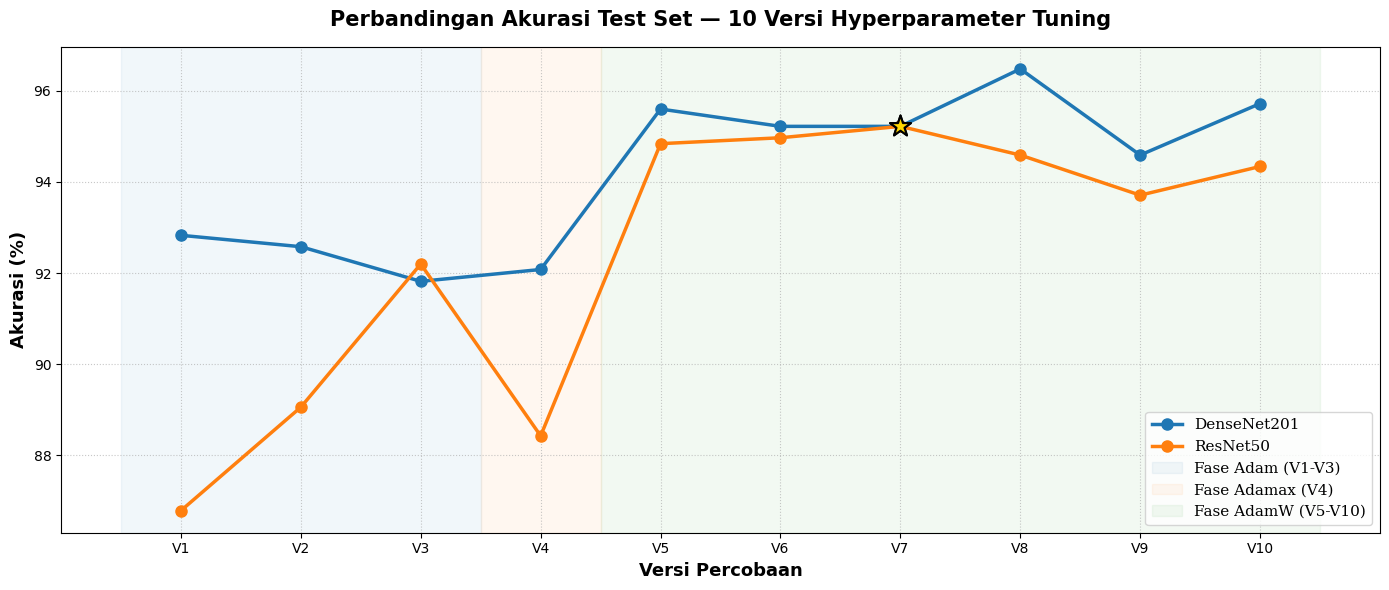

In [ ]:
"""
=============================================================================
CELL 4: PLOT PERBANDINGAN AKURASI PER VERSI
=============================================================================
Grafik ini menunjukkan perjalanan akurasi model dari V1 hingga V10.
Bintang emas menandai V7 (konfigurasi optimal).
"""

import matplotlib.pyplot as plt
import os

fig, ax = plt.subplots(figsize=(14, 6))
plt.rcParams['font.family'] = 'serif'

colors = {'DenseNet201': '#1f77b4', 'ResNet50': '#ff7f0e'}

for model_name in df_all['model'].unique():
    subset = df_all[df_all['model'] == model_name].sort_values('version')
    color = colors.get(model_name, '#333333')
    ax.plot(subset['version'], subset['accuracy'] * 100, marker='o', linewidth=2.5,
            markersize=8, label=model_name, color=color)

    # Tandai V7 (best)
    v7 = subset[subset['version'] == 7]
    if not v7.empty:
        ax.scatter(7, v7['accuracy'].values[0] * 100, s=250, c='gold',
                   edgecolors='black', zorder=5, marker='*', linewidths=1.5)

# Highlight zona optimizer
ax.axvspan(0.5, 3.5, alpha=0.06, color='#1f77b4', label='Fase Adam (V1-V3)')
ax.axvspan(3.5, 4.5, alpha=0.06, color='#ff7f0e', label='Fase Adamax (V4)')
ax.axvspan(4.5, 10.5, alpha=0.06, color='#2ca02c', label='Fase AdamW (V5-V10)')

ax.set_xlabel('Versi Percobaan', fontsize=13, fontweight='bold')
ax.set_ylabel('Akurasi (%)', fontsize=13, fontweight='bold')
ax.set_title('Perbandingan Akurasi Test Set — 10 Versi Hyperparameter Tuning',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(range(1, 11))
ax.set_xticklabels([f'V{i}' for i in range(1, 11)])
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
save_path = os.path.join(VIS_PATH, 'Comparison_Accuracy_AllVersions.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Tersimpan di: {save_path}")
plt.show()


Tersimpan di: /content/drive/MyDrive/TugasAkhir/Visualizations/Heatmap_F1_DenseNet201.png


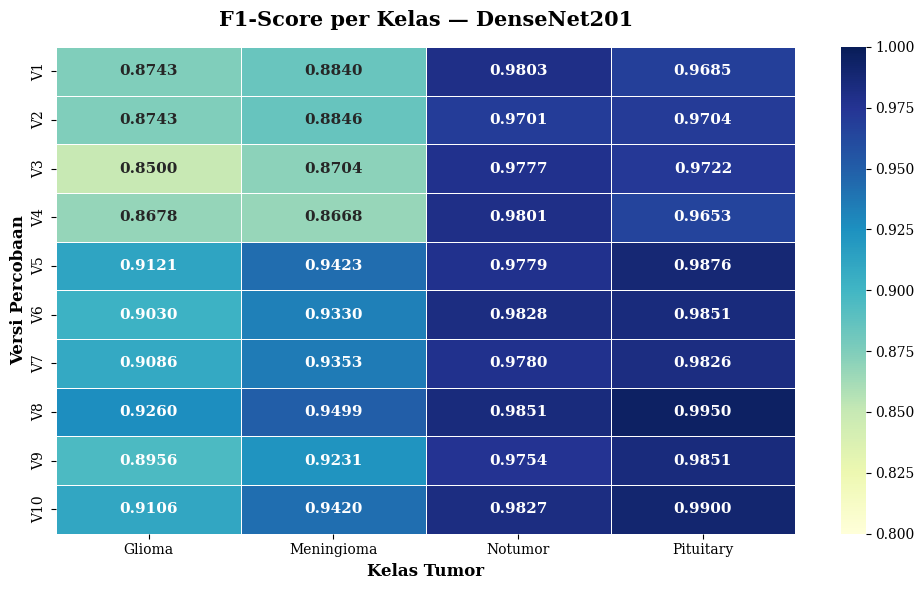

Tersimpan di: /content/drive/MyDrive/TugasAkhir/Visualizations/Heatmap_F1_ResNet50.png


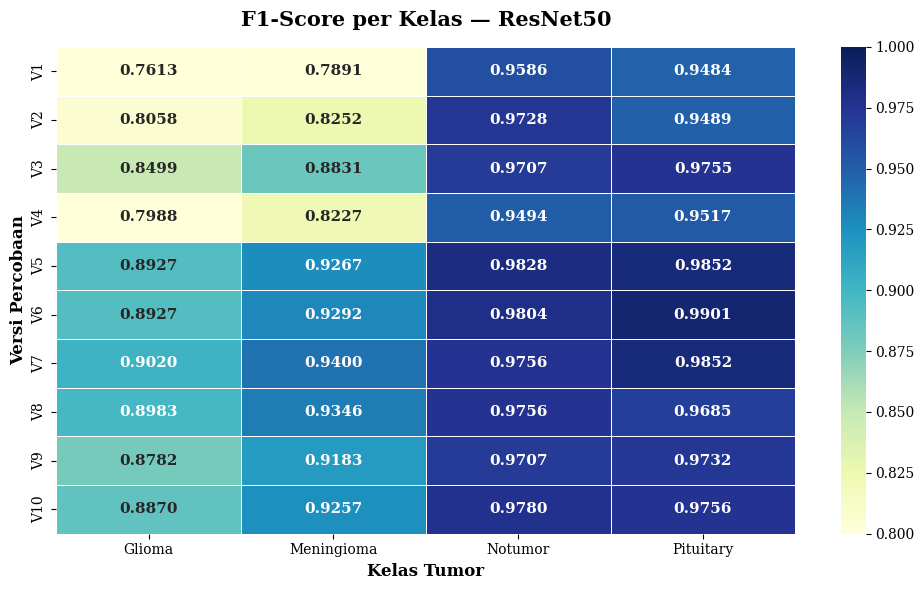

In [ ]:
"""
=============================================================================
CELL 5: HEATMAP F1-SCORE PER KELAS PER VERSI
=============================================================================
Heatmap ini menunjukkan F1-Score per kelas tumor untuk setiap versi.
Warna lebih gelap = F1 lebih tinggi.
"""

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

for model_name in df_all['model'].unique():
    subset = df_all[df_all['model'] == model_name].sort_values('version')

    f1_matrix = []
    versions = []
    for _, row in subset.iterrows():
        f1_row = [row.get(f'f1_{cls}', 0) for cls in classes]
        f1_matrix.append(f1_row)
        versions.append(f"V{int(row['version'])}")

    f1_df = pd.DataFrame(f1_matrix, index=versions,
                         columns=[c.title() for c in classes])

    fig, ax = plt.subplots(figsize=(10, 6))
    plt.rcParams['font.family'] = 'serif'
    sns.heatmap(f1_df, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax,
                vmin=0.8, vmax=1.0, linewidths=0.5,
                annot_kws={"size": 11, "weight": "bold"})
    ax.set_title(f'F1-Score per Kelas — {model_name}', fontsize=15, fontweight='bold', pad=15)
    ax.set_ylabel('Versi Percobaan', fontsize=12, fontweight='bold')
    ax.set_xlabel('Kelas Tumor', fontsize=12, fontweight='bold')
    plt.tight_layout()

    save_path = os.path.join(VIS_PATH, f'Heatmap_F1_{model_name}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Tersimpan di: {save_path}")
    plt.show()


Tersimpan di: /content/drive/MyDrive/TugasAkhir/Visualizations/Comparison_Time_Efficiency.png


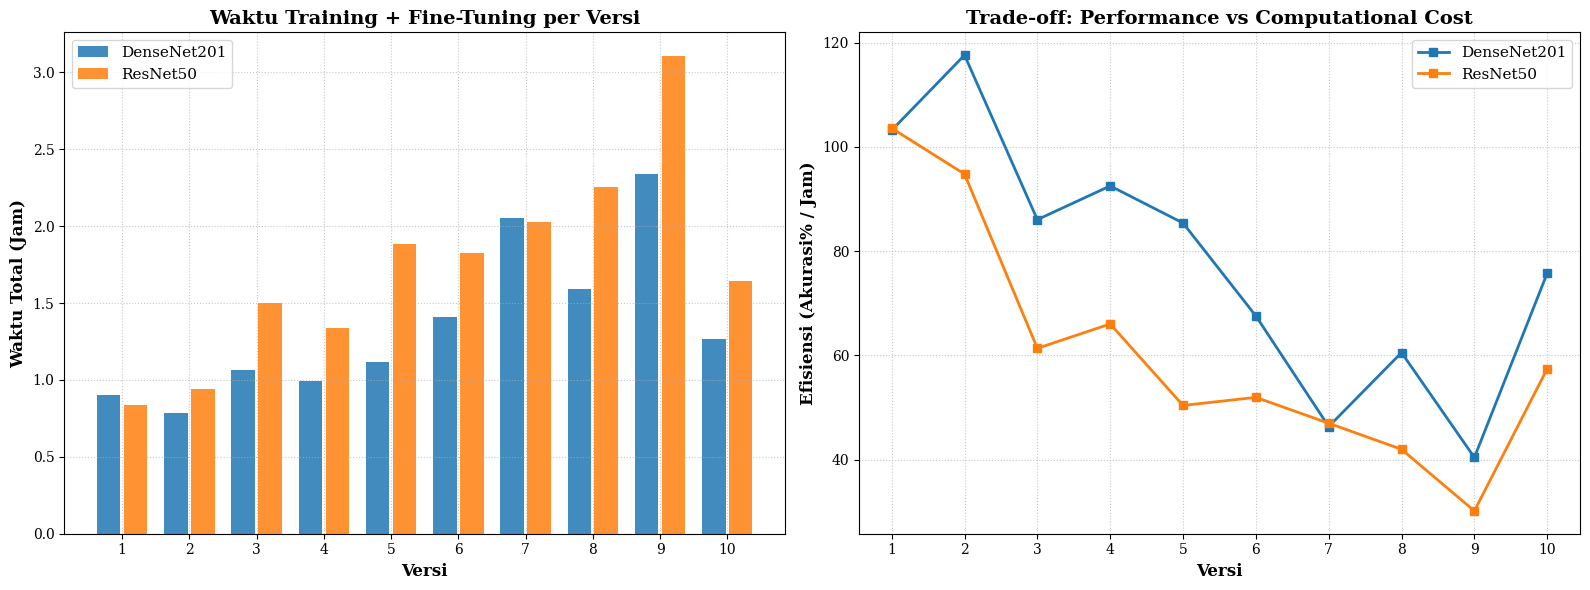

In [ ]:
"""
=============================================================================
CELL 6: WAKTU TRAINING & EFISIENSI (AKURASI PER JAM)
=============================================================================
Grafik ini menunjukkan trade-off antara performa dan biaya komputasi.
Efisiensi = Akurasi (%) / Waktu Total (Jam)
"""

import matplotlib.pyplot as plt
import os

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.rcParams['font.family'] = 'serif'

colors = {'DenseNet201': '#1f77b4', 'ResNet50': '#ff7f0e'}
bar_width = 0.35
offset = {'DenseNet201': -0.2, 'ResNet50': 0.2}

for model_name in df_all['model'].unique():
    subset = df_all[df_all['model'] == model_name].sort_values('version')
    total_hours = subset['total_time_sec'] / 3600
    color = colors.get(model_name, '#333333')

    # Plot: Waktu Total
    axes[0].bar(subset['version'] + offset.get(model_name, 0),
                total_hours, width=bar_width, label=model_name,
                alpha=0.85, color=color)

    # Plot: Efisiensi
    efficiency = (subset['accuracy'].values * 100) / total_hours.values
    axes[1].plot(subset['version'], efficiency, marker='s', linewidth=2,
                 label=model_name, color=color)

axes[0].set_xlabel('Versi', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Waktu Total (Jam)', fontsize=12, fontweight='bold')
axes[0].set_title('Waktu Training + Fine-Tuning per Versi', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(1, 11))
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.7)

axes[1].set_xlabel('Versi', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Efisiensi (Akurasi% / Jam)', fontsize=12, fontweight='bold')
axes[1].set_title('Trade-off: Performance vs Computational Cost', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(1, 11))
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
save_path = os.path.join(VIS_PATH, 'Comparison_Time_Efficiency.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Tersimpan di: {save_path}")
plt.show()


In [ ]:
"""
=============================================================================
CELL 7: TABEL RINGKASAN LENGKAP SEMUA VERSI
=============================================================================
"""

import pandas as pd
import os

print("=" * 80)
print("TABEL RINGKASAN SEMUA VERSI")
print("=" * 80)

summary_cols = ['version', 'model', 'accuracy', 'f1_macro', 'precision_macro', 'recall_macro',
                'training_time_sec', 'finetuning_time_sec', 'total_time_sec',
                'train_epochs', 'ft_epochs', 'optimizer', 'dropout', 'batch_size']

# Filter kolom yang tersedia
available_cols = [c for c in summary_cols if c in df_all.columns]
display_df = df_all[available_cols].sort_values(['model', 'version'])

print(display_df.to_string(index=False))

# Simpan ke Drive
save_path = os.path.join(RESULTS_PATH, 'full_comparison_table.csv')
display_df.to_csv(save_path, index=False)
print(f"\nTersimpan di: {save_path}")

# Highlight best version per model
print("\n" + "=" * 80)
print("MODEL TERBAIK PER ARSITEKTUR")
print("=" * 80)
for model_name in df_all['model'].unique():
    subset = df_all[df_all['model'] == model_name]
    best = subset.loc[subset['accuracy'].idxmax()]
    print(f"  {model_name}: V{int(best['version'])} — Accuracy={best['accuracy']*100:.2f}%, F1={best['f1_macro']:.4f}")


TABEL RINGKASAN SEMUA VERSI
 version       model  accuracy  f1_macro  precision_macro  recall_macro  training_time_sec  finetuning_time_sec  total_time_sec  train_epochs  ft_epochs optimizer  dropout  batch_size
       1 DenseNet201    0.9283    0.9268           0.9285        0.9276            2085.21              1153.53         3238.74            25         13      Adam      0.3          32
       2 DenseNet201    0.9258    0.9249           0.9273        0.9251            1810.12              1024.33         2834.45            24         13      Adam      0.3          32
       3 DenseNet201    0.9182    0.9175           0.9232        0.9174            2302.48              1539.48         3841.96            26         17      Adam      0.3          32
       4 DenseNet201    0.9208    0.9200           0.9207        0.9206            2375.14              1208.30         3583.45            33         16    Adamax      0.3          32
       5 DenseNet201    0.9560    0.9550           0

## Bagian C: Evaluasi Model Terbaik (V7)

In [ ]:
"""
=============================================================================
CELL 8: LOAD MODEL TERBAIK (V7) DARI GOOGLE DRIVE
=============================================================================
"""

import os
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras import backend as K

tf.get_logger().setLevel('ERROR')

print("=" * 70)
print("MEMUAT MODEL TERBAIK (V7) DARI GOOGLE DRIVE")
print("=" * 70)

# Prioritas: Saved_Models > Models
model_dirs = [
    '/content/drive/MyDrive/TugasAkhir/Models',
    '/content/drive/MyDrive/TugasAkhir/Saved_Models',
]

models = {}
model_names = ['DenseNet201', 'ResNet50']

for model_name in model_names:
    loaded = False
    # Cari file model di berbagai lokasi dan format nama
    search_patterns = [
        f'Best_FineTuned_{model_name}.keras',
        f'Best_Model_{model_name}.keras',
        f'Final_{model_name}.keras',
    ]
    for model_dir in model_dirs:
        for pattern in search_patterns:
            path = os.path.join(model_dir, pattern)
            if os.path.exists(path):
                print(f"\n  Memuat {model_name} dari: {path}")
                models[model_name] = load_model(path)
                size_mb = os.path.getsize(path) / (1024*1024)
                print(f"  Ukuran file: {size_mb:.1f} MB")
                print(f"  Total params: {models[model_name].count_params():,}")
                loaded = True
                break
        if loaded:
            break
    if not loaded:
        print(f"\n  WARNING: Model {model_name} tidak ditemukan!")

print("\n" + "=" * 70)
print(f"Model yang berhasil dimuat: {list(models.keys())}")
print("=" * 70)


MEMUAT MODEL TERBAIK (V7) DARI GOOGLE DRIVE

  Memuat DenseNet201 dari: /content/drive/MyDrive/TugasAkhir/Models/Final_DenseNet201.keras
  Ukuran file: 124.9 MB
  Total params: 18,329,668

  Memuat ResNet50 dari: /content/drive/MyDrive/TugasAkhir/Models/Final_ResNet50.keras
  Ukuran file: 204.8 MB
  Total params: 23,595,908

Model yang berhasil dimuat: ['DenseNet201', 'ResNet50']


EVALUASI FINAL: DENSENET201

BENCHMARK KECEPATAN INFERENSI...
        1 gambar : 0.4355 detik
       10 gambar : 2.4295 detik
       50 gambar : 20.5485 detik
      100 gambar : 41.0822 detik
      150 gambar : 82.0741 detik
      200 gambar : 82.1162 detik

Memproses prediksi pada Test Set...

              precision    recall  f1-score   support

      glioma     0.9829    0.8821    0.9297       195
  meningioma     0.9378    0.9800    0.9584       200
     notumor     0.9662    1.0000    0.9828       200
   pituitary     0.9804    1.0000    0.9901       200

    accuracy                         0.9660       795
   macro avg     0.9668    0.9655    0.9653       795
weighted avg     0.9667    0.9660    0.9655       795

Overall Accuracy: 96.6038%
[+] Report tersimpan: /content/drive/MyDrive/TugasAkhir/Visualizations/Classification_Report_DenseNet201.png


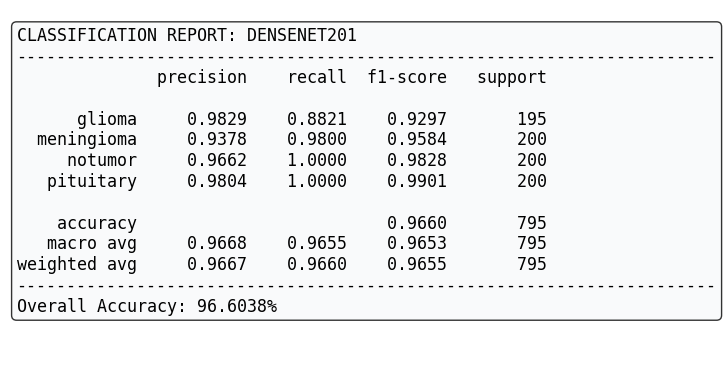

[+] Confusion Matrix tersimpan: /content/drive/MyDrive/TugasAkhir/Visualizations/Confusion_Matrix_DenseNet201.png


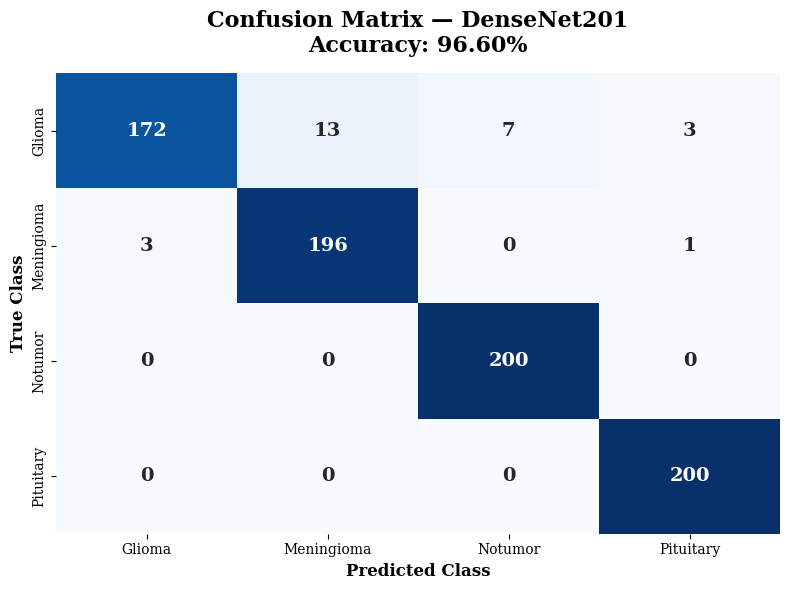

EVALUASI FINAL: RESNET50

BENCHMARK KECEPATAN INFERENSI...
        1 gambar : 0.2727 detik
       10 gambar : 2.6067 detik
       50 gambar : 10.2908 detik
      100 gambar : 17.1473 detik
      150 gambar : 41.1241 detik
      200 gambar : 35.8896 detik

Memproses prediksi pada Test Set...

              precision    recall  f1-score   support

      glioma     1.0000    0.8256    0.9045       195
  meningioma     0.8879    0.9900    0.9362       200
     notumor     0.9662    1.0000    0.9828       200
   pituitary     0.9804    1.0000    0.9901       200

    accuracy                         0.9547       795
   macro avg     0.9586    0.9539    0.9534       795
weighted avg     0.9584    0.9547    0.9537       795

Overall Accuracy: 95.4717%
[+] Report tersimpan: /content/drive/MyDrive/TugasAkhir/Visualizations/Classification_Report_ResNet50.png


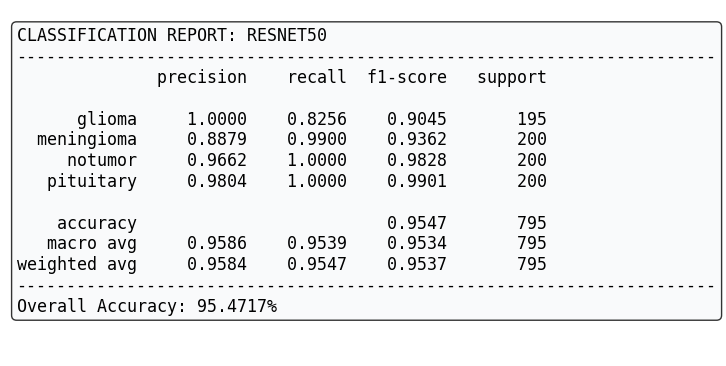

[+] Confusion Matrix tersimpan: /content/drive/MyDrive/TugasAkhir/Visualizations/Confusion_Matrix_ResNet50.png


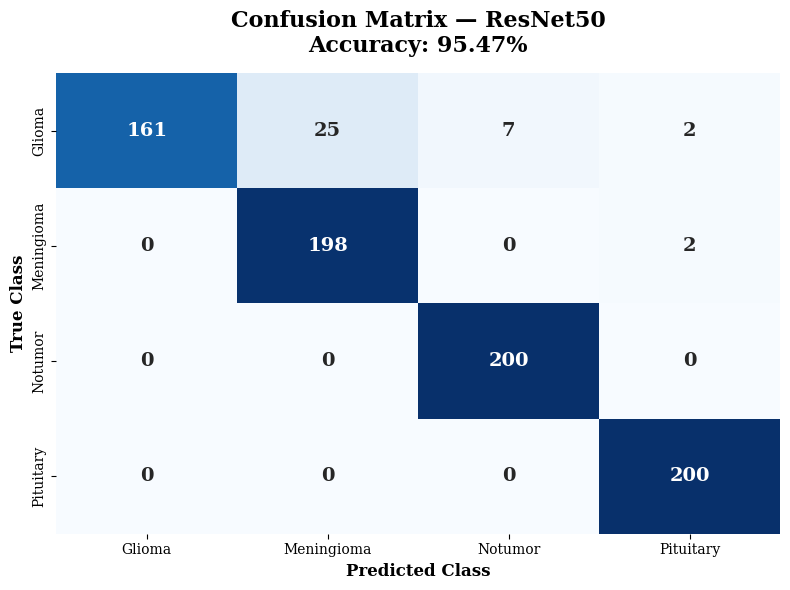

In [ ]:
"""
=============================================================================
CELL 9: EVALUASI MODEL TERBAIK — CLASSIFICATION REPORT & CONFUSION MATRIX
=============================================================================
Menghasilkan:
1. Classification Report (text + gambar PNG)
2. Confusion Matrix (gambar PNG)
3. Inference Benchmark (1, 10, 50, 100, 150, 200 gambar)
Semua output disimpan otomatis ke Google Drive.
"""

import os, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def evaluate_best_model(model, model_name, test_gen):
    print("=" * 80)
    print(f"EVALUASI FINAL: {model_name.upper()}")
    print("=" * 80)

    vis_dir = VIS_PATH
    os.makedirs(vis_dir, exist_ok=True)

    # =====================================================================
    # 1. BENCHMARK KECEPATAN INFERENSI
    # =====================================================================
    print("\nBENCHMARK KECEPATAN INFERENSI...")
    X_bench = []
    test_gen.reset()
    for _ in range(len(test_gen)):
        x_batch, _ = next(test_gen)
        X_bench.extend(x_batch)
        if len(X_bench) >= 200: break
    X_bench = np.array(X_bench[:200])

    benchmark_results = {}
    for n in [1, 10, 50, 100, 150, 200]:
        subset = X_bench[:n]
        _ = model.predict(subset, batch_size=32, verbose=0)  # warm-up
        start_t = time.time()
        _ = model.predict(subset, batch_size=32, verbose=0)
        elapsed = time.time() - start_t
        benchmark_results[n] = elapsed
        print(f"      {n:>3} gambar : {elapsed:.4f} detik")

    # =====================================================================
    # 2. PREDIKSI PENUH & CLASSIFICATION REPORT
    # =====================================================================
    print("\nMemproses prediksi pada Test Set...")
    test_gen.reset()
    predictions_prob = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(predictions_prob, axis=1)
    y_true = test_gen.classes
    class_names = list(test_gen.class_indices.keys())
    acc = accuracy_score(y_true, y_pred)

    report_text = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print(f"\n{report_text}")
    print(f"Overall Accuracy: {acc*100:.4f}%")

    # --- Classification Report sebagai gambar ---
    plt.rcParams['font.family'] = 'serif'
    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    ax.axis('off')
    full_text = f"CLASSIFICATION REPORT: {model_name.upper()}\n"
    full_text += "-" * 70 + "\n" + report_text + "-" * 70 + "\n"
    full_text += f"Overall Accuracy: {acc*100:.4f}%"
    ax.text(0.01, 0.95, full_text, family='monospace', fontsize=12,
            verticalalignment='top', color='black',
            bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.8))
    cr_path = os.path.join(vis_dir, f'Classification_Report_{model_name}.png')
    plt.savefig(cr_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"[+] Report tersimpan: {cr_path}")
    plt.show()

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=[c.title() for c in class_names],
                yticklabels=[c.title() for c in class_names],
                annot_kws={"size": 14, "weight": "bold"})
    plt.title(f'Confusion Matrix — {model_name}\nAccuracy: {acc*100:.2f}%',
              fontsize=16, fontweight='bold', pad=15)
    plt.ylabel('True Class', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')
    plt.tight_layout()
    cm_path = os.path.join(vis_dir, f'Confusion_Matrix_{model_name}.png')
    plt.savefig(cm_path, dpi=300, bbox_inches='tight')
    print(f"[+] Confusion Matrix tersimpan: {cm_path}")
    plt.show()

    return acc, benchmark_results

# --- EKSEKUSI ---
try:
    results_best = {}
    for name in ['DenseNet201', 'ResNet50']:
        if name in models:
            test_gen = test_gen_dense if name == 'DenseNet201' else test_gen_resnet
            acc, bench = evaluate_best_model(models[name], name, test_gen)
            results_best[name] = {'accuracy': acc, 'benchmark': bench}
except Exception as e:
    import traceback
    print(f"Error: {e}")
    traceback.print_exc()


## Bagian D: Explainable AI — Score-CAM


MENCARI CITRA KANDIDAT BERSAMA (SHARED TRUE POSITIVES)...
     Citra kandidat bersama berhasil dikumpulkan!

MEMULAI RENDER SCORE-CAM: DENSENET201
   Layer Feature Extractor: 'relu'

     Memproses Kelas: Glioma...
      - Selesai dalam 2308.74 detik
     Memproses Kelas: Meningioma...
      - Selesai dalam 2323.49 detik
     Memproses Kelas: Notumor...
      - Selesai dalam 2333.11 detik
     Memproses Kelas: Pituitary...
      - Selesai dalam 2340.36 detik
--------------------------------------------------
     TOTAL WAKTU RENDER DenseNet201: 9305.70 detik
--------------------------------------------------
     Gambar tersimpan aman di: /content/drive/MyDrive/TugasAkhir/Visualizations/ScoreCAM_DenseNet201.png


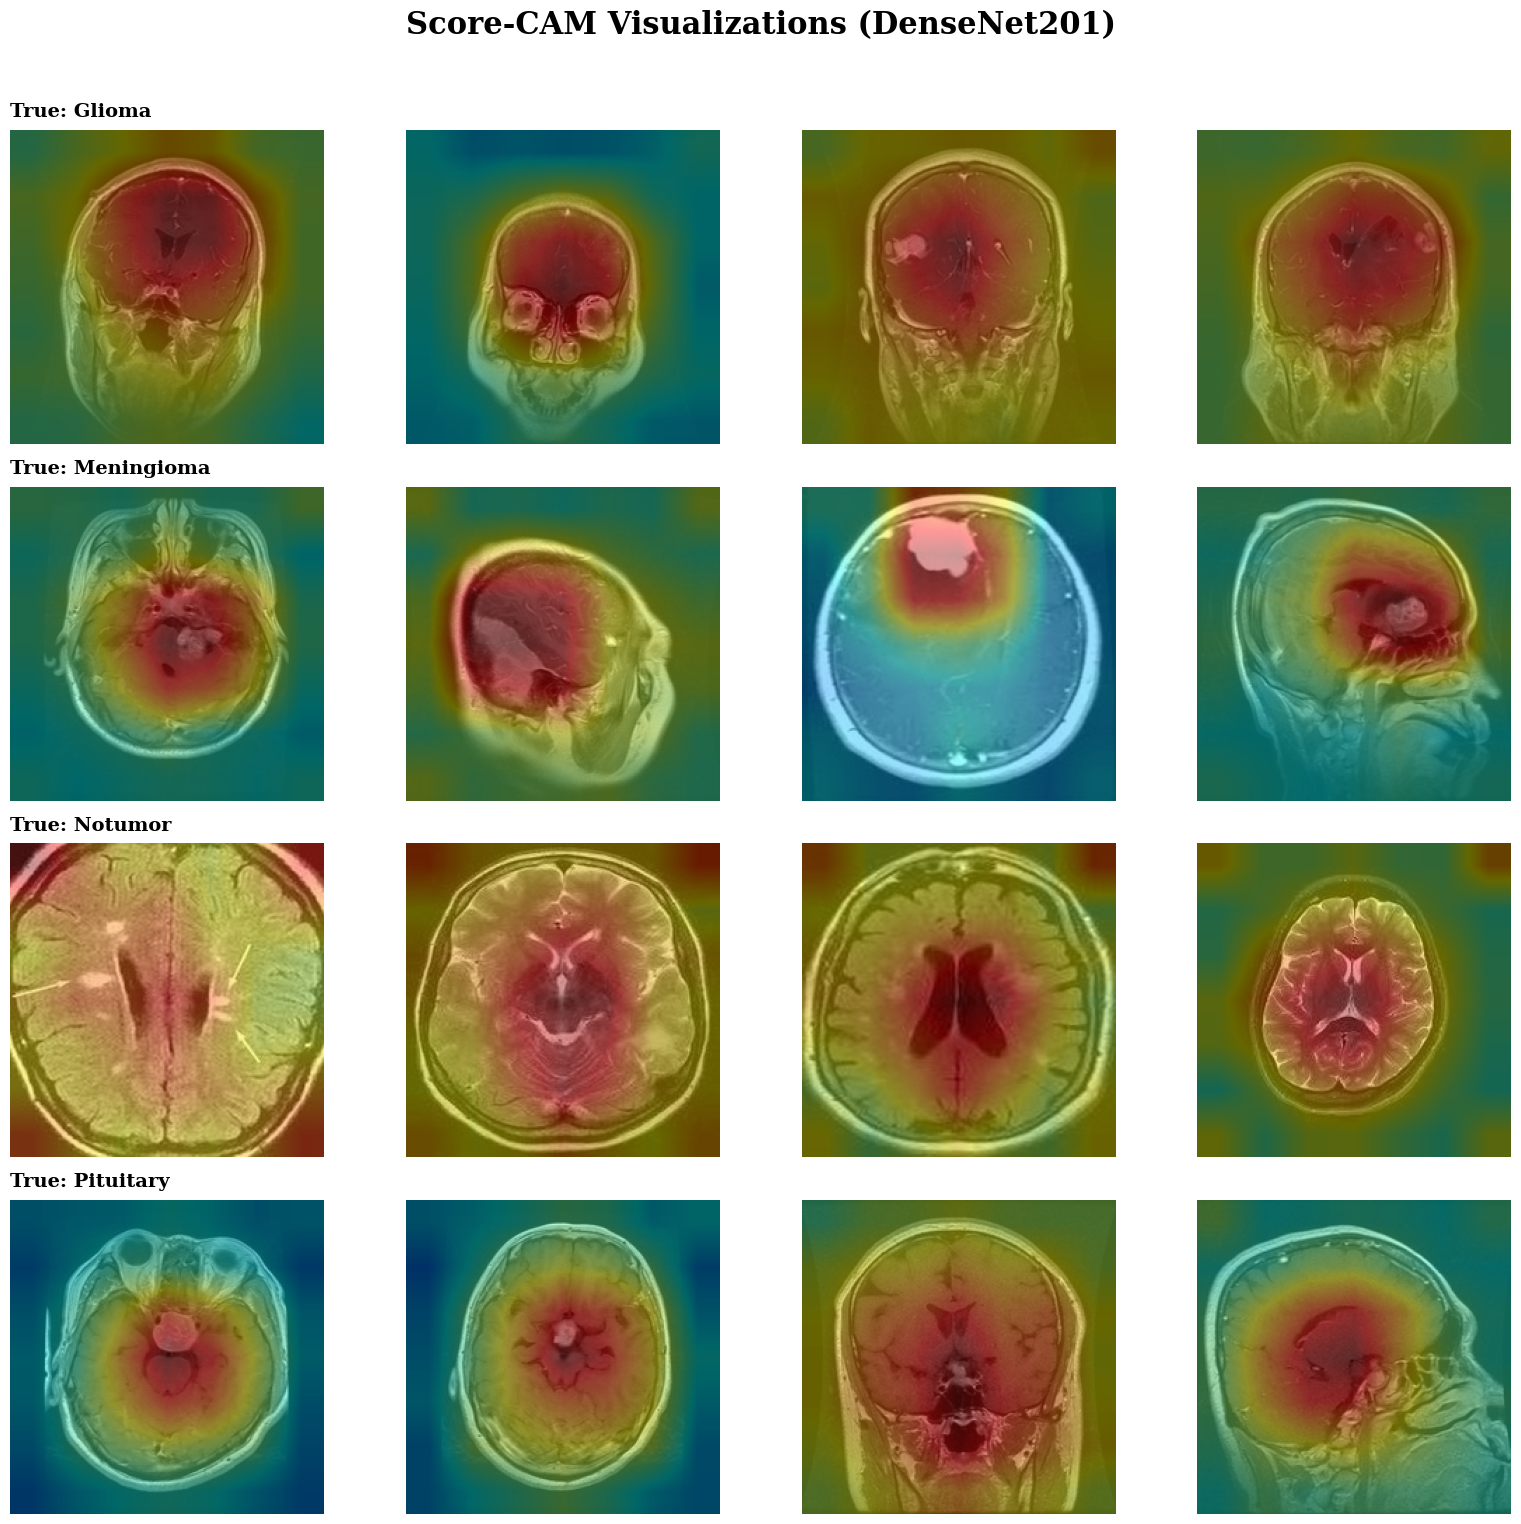


MEMULAI RENDER SCORE-CAM: RESNET50
   Layer Feature Extractor: 'conv5_block3_out'

     Memproses Kelas: Glioma...
      - Selesai dalam 1945.79 detik
     Memproses Kelas: Meningioma...
      - Selesai dalam 1962.60 detik
     Memproses Kelas: Notumor...
      - Selesai dalam 1928.02 detik
     Memproses Kelas: Pituitary...
      - Selesai dalam 2066.21 detik
--------------------------------------------------
     TOTAL WAKTU RENDER ResNet50: 7902.63 detik
--------------------------------------------------
     Gambar tersimpan aman di: /content/drive/MyDrive/TugasAkhir/Visualizations/ScoreCAM_ResNet50.png


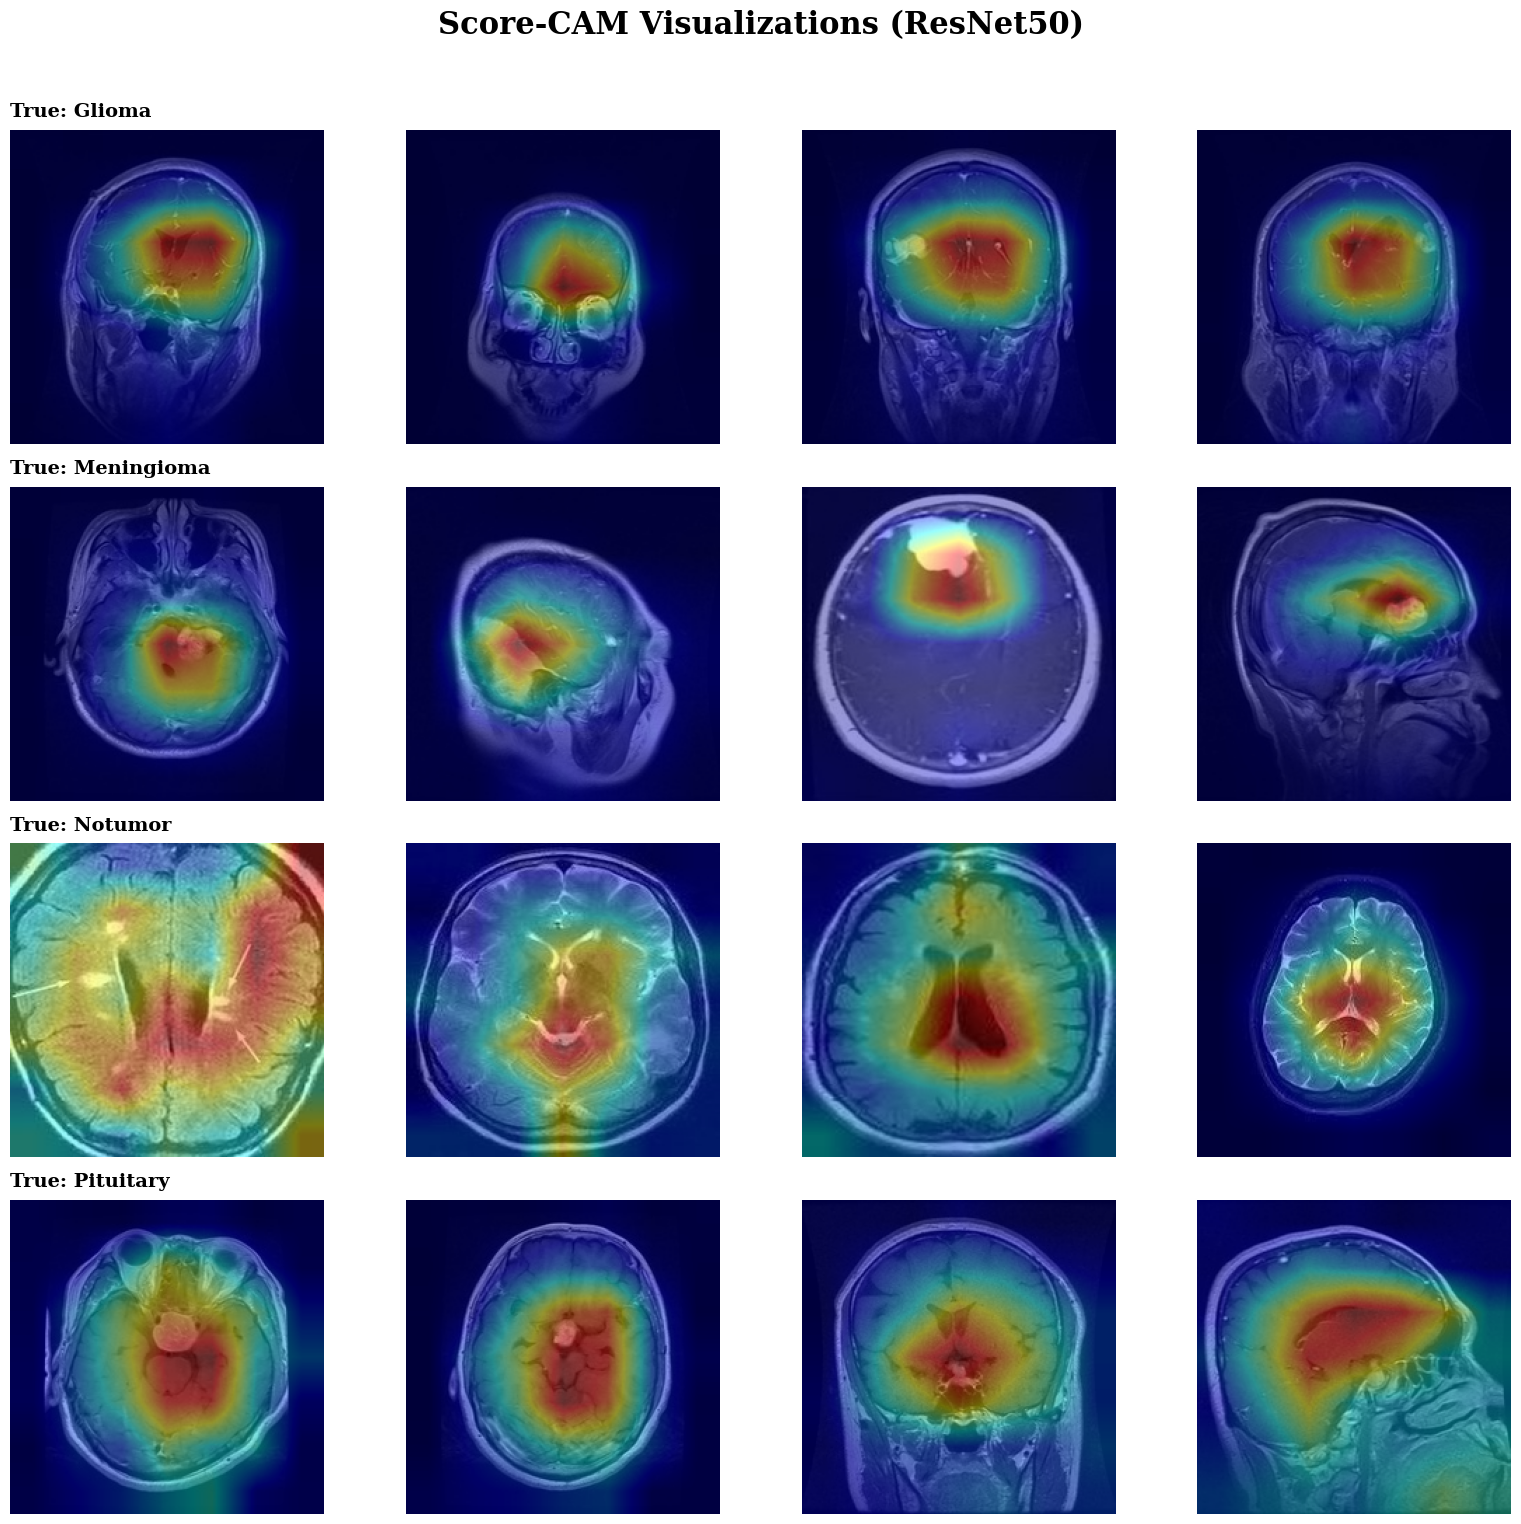

In [ ]:
"""
=============================================================================
CELL 10: EXPLAINABLE AI - SCORE-CAM VISUALIZATION
=============================================================================
1. Mencari citra (True Positives) yang berhasil ditebak BENAR oleh KEDUA model.
2. Menghitung waktu komputasi XAI secara spesifik per kelas dan keseluruhan.
3. Menghasilkan visualisasi Heatmap perbandingan.
4. Menyimpan output secara otomatis ke Google Drive.
"""

import os
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.densenet import preprocess_input as densenet_prep
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_prep

# Menonaktifkan peringatan TF untuk log yang lebih bersih
tf.get_logger().setLevel('ERROR')

def get_last_conv_layer(model):
    """Mencari layer konvolusi 4D terakhir secara dinamis."""
    for layer in reversed(model.layers):
        try:
            shape = layer.output_shape if hasattr(layer, 'output_shape') else layer.output.shape
            if isinstance(shape, list):
                shape = shape[0]
            if len(shape) == 4:
                return layer.name
        except Exception:
            continue
    raise ValueError("Tidak dapat menemukan layer konvolusi 4D di dalam model.")

def generate_scorecam_heatmap(model, img_array, class_index, last_conv_layer_name, batch_size=64):
    """Algoritma Score-CAM Inti."""
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    activations, _ = grad_model([img_array])
    activations = activations[0].numpy()

    num_channels = activations.shape[-1]
    input_shape = (img_array.shape[1], img_array.shape[2])

    upsampled_activations = np.zeros((num_channels, input_shape[0], input_shape[1]))
    for i in range(num_channels):
        act = activations[:, :, i]
        act = cv2.resize(act, input_shape)
        act_min, act_max = act.min(), act.max()
        if act_max - act_min > 1e-7:
            act = (act - act_min) / (act_max - act_min)
        else:
            act = np.zeros_like(act)
        upsampled_activations[i] = act

    masked_images = np.zeros((num_channels, input_shape[0], input_shape[1], 3))
    for i in range(num_channels):
        masked_images[i] = img_array[0] * np.expand_dims(upsampled_activations[i], axis=-1)

    scores = np.zeros(num_channels)
    for i in range(0, num_channels, batch_size):
        batch = masked_images[i : i+batch_size]
        preds = model.predict(batch, verbose=0)
        scores[i : i+batch_size] = preds[:, class_index]

    cam = np.zeros(input_shape, dtype=np.float32)
    for i in range(num_channels):
        cam += scores[i] * upsampled_activations[i]

    cam = np.maximum(cam, 0)
    cam_max = cam.max()
    if cam_max > 1e-7:
        cam = cam / cam_max

    return cam

def find_shared_true_positives(model_a, prep_a, model_b, prep_b, test_gen, samples_per_class=4):
    """
    Mencari gambar yang berhasil ditebak BENAR oleh KEDUA model
    untuk memastikan perbandingan visual yang 100% adil.
    """
    print("\nMENCARI CITRA KANDIDAT BERSAMA (SHARED TRUE POSITIVES)...")
    class_names = list(test_gen.class_indices.keys())
    shared_cands = {i: [] for i in range(len(class_names))}

    filepaths = test_gen.filepaths
    labels = test_gen.classes

    # Acak urutan pencarian agar gambar yang diambil bervariasi
    indices = np.arange(len(filepaths))
    np.random.seed(42)
    np.random.shuffle(indices)

    for idx in indices:
        if all(len(cands) == samples_per_class for cands in shared_cands.values()):
            break # Selesai jika semua kelas sudah terpenuhi

        img_path = filepaths[idx]
        true_class_idx = labels[idx]

        if len(shared_cands[true_class_idx]) >= samples_per_class:
            continue

        # Pemuatan gambar mentah
        raw_img = load_img(img_path, target_size=(224, 224))
        raw_img_array = img_to_array(raw_img)
        img_array_expanded = np.expand_dims(raw_img_array, axis=0)

        # Tes Model A (DenseNet)
        prep_a_img = prep_a(np.copy(img_array_expanded))
        pred_a = np.argmax(model_a.predict(prep_a_img, verbose=0), axis=1)[0]

        # Tes Model B (ResNet)
        prep_b_img = prep_b(np.copy(img_array_expanded))
        pred_b = np.argmax(model_b.predict(prep_b_img, verbose=0), axis=1)[0]

        # Hanya simpan jika KEDUA model menebak dengan benar
        if pred_a == true_class_idx and pred_b == true_class_idx:
            shared_cands[true_class_idx].append(img_path)

    print("     Citra kandidat bersama berhasil dikumpulkan!")
    return shared_cands

def visualize_scorecam_shared(model, model_name, shared_cands, test_gen, prep_func):
    print("\n" + "="*80)
    print(f"MEMULAI RENDER SCORE-CAM: {model_name.upper()}")
    print("="*80)

    vis_dir = VIS_PATH  # Menggunakan path dari Cell Setup
    os.makedirs(vis_dir, exist_ok=True)

    class_names = list(test_gen.class_indices.keys())
    reverse_class_indices = {v: k for k, v in test_gen.class_indices.items()}
    samples_per_class = len(shared_cands[0])

    last_conv_layer = get_last_conv_layer(model)
    print(f"   Layer Feature Extractor: '{last_conv_layer}'\n")

    fig, axes = plt.subplots(len(class_names), samples_per_class, figsize=(16, 16))
    plt.rcParams['font.family'] = 'serif'

    total_start_time = time.time()

    for class_idx in range(len(class_names)):
        img_paths = shared_cands[class_idx]
        class_name_str = reverse_class_indices[class_idx].title()

        print(f"     Memproses Kelas: {class_name_str}...")
        class_start_time = time.time()

        for sample_idx, img_path in enumerate(img_paths):
            ax = axes[class_idx, sample_idx]

            raw_img = load_img(img_path, target_size=(224, 224))
            raw_img_array = img_to_array(raw_img)
            prep_img_array = prep_func(np.expand_dims(np.copy(raw_img_array), axis=0))

            heatmap = generate_scorecam_heatmap(
                model=model,
                img_array=prep_img_array,
                class_index=class_idx,
                last_conv_layer_name=last_conv_layer
            )

            heatmap_resized = cv2.resize(heatmap, (224, 224))
            heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
            heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

            superimposed_img = heatmap_color * 0.4 + raw_img_array * 0.6
            superimposed_img = np.clip(superimposed_img, 0, 255).astype('uint8')

            ax.imshow(superimposed_img)
            ax.axis('off')

            if sample_idx == 0:
                ax.set_title(f"True: {class_name_str}", loc='left', fontsize=14, fontweight='bold', pad=10)

        class_end_time = time.time()
        print(f"      - Selesai dalam {(class_end_time - class_start_time):.2f} detik")

    total_end_time = time.time()
    print("-" * 50)
    print(f"     TOTAL WAKTU RENDER {model_name}: {(total_end_time - total_start_time):.2f} detik")
    print("-" * 50)

    plt.suptitle(f"Score-CAM Visualizations ({model_name})", fontsize=22, fontweight='bold', y=0.95)
    plt.tight_layout(rect=[0, 0, 1, 0.93])

    save_path = os.path.join(vis_dir, f'ScoreCAM_{model_name}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"     Gambar tersimpan aman di: {save_path}")
    plt.show()

# --- EKSEKUSI ---
try:
    # Ambil model dari dictionary yang dimuat di Cell 8
    if 'DenseNet201' not in models or 'ResNet50' not in models:
        raise NameError("Model belum dimuat. Jalankan Cell 8 (Load Model Terbaik) terlebih dahulu.")

    model_densenet = models['DenseNet201']
    model_resnet = models['ResNet50']

    # 1. CARI CITRA KANDIDAT BERSAMA (Hanya dieksekusi sekali)
    shared_candidates = find_shared_true_positives(
        model_a=model_densenet, prep_a=densenet_prep,
        model_b=model_resnet, prep_b=resnet_prep,
        test_gen=test_gen_dense, samples_per_class=4
    )

    # 2. RENDER DENSENET201
    visualize_scorecam_shared(
        model=model_densenet, model_name='DenseNet201',
        shared_cands=shared_candidates, test_gen=test_gen_dense, prep_func=densenet_prep
    )

    # 3. RENDER RESNET-50
    visualize_scorecam_shared(
        model=model_resnet, model_name='ResNet50',
        shared_cands=shared_candidates, test_gen=test_gen_resnet, prep_func=resnet_prep
    )

except Exception as e:
    import traceback
    print(f"Terjadi kesalahan: {e}")
    traceback.print_exc()

## Bagian E: Analisis Tambahan

In [ ]:
"""
=============================================================================
CELL 11: EVALUASI EFISIENSI & KOMPLEKSITAS KOMPUTASI
=============================================================================
Mengukur:
- Ukuran model (MB) via numpy ground truth
- FLOPs (Floating Point Operations)
- Latency per gambar
- Perbandingan antar arsitektur
Semua output disimpan ke Google Drive.
"""

import os
import time
import numpy as np
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import (
    convert_variables_to_constants_v2_as_graph
)
import matplotlib.pyplot as plt

tf.get_logger().setLevel('ERROR')

# =========================================================================
# FUNGSI UTILITAS
# =========================================================================
def get_true_model_size(model, model_name):
    size_numpy_mb = sum(w.numpy().nbytes for w in model.weights) / (1024**2)
    size_theoretical = model.count_params() * 4 / (1024**2)
    print(f"\n   Ukuran {model_name}:")
    print(f"   ├─ Numpy Direct (GROUND TRUTH) : {size_numpy_mb:.2f} MB")
    print(f"   └─ Teoritis float32 minimum     : {size_theoretical:.2f} MB")
    return size_numpy_mb

def get_flops_exact(model):
    concrete = tf.function(lambda inputs: model(inputs))
    specs = [tf.TensorSpec([1, *inp.shape[1:]], dtype=tf.float32) for inp in model.inputs]
    concrete_func = concrete.get_concrete_function(specs[0] if len(specs) == 1 else specs)
    frozen_func, graph_def = convert_variables_to_constants_v2_as_graph(concrete_func)
    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name='')
        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        opts['output'] = 'none'
        flops = tf.compat.v1.profiler.profile(graph=graph, run_meta=run_meta, cmd='op', options=opts)
        return flops.total_float_ops

# =========================================================================
# ANALISIS
# =========================================================================
print("=" * 80)
print("EVALUASI EFISIENSI & KOMPLEKSITAS KOMPUTASI")
print("=" * 80)

efficiency_data = {}
dummy_input = np.random.rand(1, 224, 224, 3).astype(np.float32)

for model_name in ['DenseNet201', 'ResNet50']:
    if model_name not in models:
        print(f"  SKIP: {model_name} tidak dimuat")
        continue

    model = models[model_name]
    print(f"\n{'─'*60}")
    print(f"ARSITEKTUR: {model_name}")
    print(f"{'─'*60}")

    # 1. Ukuran Model
    size_mb = get_true_model_size(model, model_name)

    # 2. Parameter
    total_params = model.count_params()
    trainable = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
    non_trainable = total_params - trainable
    print(f"\n   Parameter:")
    print(f"   ├─ Total      : {total_params:,}")
    print(f"   ├─ Trainable  : {trainable:,}")
    print(f"   └─ Frozen     : {non_trainable:,}")

    # 3. FLOPs
    try:
        flops = get_flops_exact(model)
        gflops = flops / 1e9
        print(f"\n   FLOPs: {flops:,} ({gflops:.2f} GFLOPs)")
    except Exception as e:
        flops = 0
        gflops = 0
        print(f"\n   FLOPs: Error ({e})")

    # 4. Latency
    _ = model.predict(dummy_input, verbose=0)  # warm-up
    times = []
    for _ in range(10):
        start = time.time()
        _ = model.predict(dummy_input, verbose=0)
        times.append(time.time() - start)
    avg_latency = np.mean(times)
    print(f"\n   Latency (rata-rata 10x): {avg_latency*1000:.2f} ms/gambar")

    efficiency_data[model_name] = {
        'size_mb': size_mb, 'total_params': total_params,
        'trainable': trainable, 'gflops': gflops,
        'latency_ms': avg_latency * 1000,
        'accuracy': results_best.get(model_name, {}).get('accuracy', 0)
    }

# =========================================================================
# TABEL PERBANDINGAN
# =========================================================================
if efficiency_data:
    print("\n\n" + "=" * 80)
    print("TABEL PERBANDINGAN EFISIENSI (UNTUK SKRIPSI BAB 4)")
    print("=" * 80)
    header = f"{'Metrik':<25} | {'DenseNet201':>15} | {'ResNet50':>15}"
    print(header)
    print("-" * len(header))

    d = efficiency_data.get('DenseNet201', {})
    r = efficiency_data.get('ResNet50', {})

    rows = [
        ('Accuracy (%)', f"{d.get('accuracy',0)*100:.2f}", f"{r.get('accuracy',0)*100:.2f}"),
        ('Model Size (MB)', f"{d.get('size_mb',0):.2f}", f"{r.get('size_mb',0):.2f}"),
        ('Total Parameters', f"{d.get('total_params',0):,}", f"{r.get('total_params',0):,}"),
        ('Trainable Params', f"{d.get('trainable',0):,}", f"{r.get('trainable',0):,}"),
        ('GFLOPs', f"{d.get('gflops',0):.2f}", f"{r.get('gflops',0):.2f}"),
        ('Latency (ms/img)', f"{d.get('latency_ms',0):.2f}", f"{r.get('latency_ms',0):.2f}"),
    ]
    for label, dv, rv in rows:
        print(f"{label:<25} | {dv:>15} | {rv:>15}")


EVALUASI EFISIENSI & KOMPLEKSITAS KOMPUTASI

────────────────────────────────────────────────────────────
ARSITEKTUR: DenseNet201
────────────────────────────────────────────────────────────

   Ukuran DenseNet201:
   ├─ Numpy Direct (GROUND TRUTH) : 69.92 MB
   └─ Teoritis float32 minimum     : 69.92 MB

   Parameter:
   ├─ Total      : 18,329,668
   ├─ Trainable  : 6,888,964
   └─ Frozen     : 11,440,704

   FLOPs: 8,631,683,288 (8.63 GFLOPs)

   Latency (rata-rata 10x): 361.92 ms/gambar

────────────────────────────────────────────────────────────
ARSITEKTUR: ResNet50
────────────────────────────────────────────────────────────

   Ukuran ResNet50:
   ├─ Numpy Direct (GROUND TRUTH) : 90.01 MB
   └─ Teoritis float32 minimum     : 90.01 MB

   Parameter:
   ├─ Total      : 23,595,908
   ├─ Trainable  : 14,961,668
   └─ Frozen     : 8,634,240

   FLOPs: 7,751,213,720 (7.75 GFLOPs)

   Latency (rata-rata 10x): 307.34 ms/gambar


TABEL PERBANDINGAN EFISIENSI (UNTUK SKRIPSI BAB 4)
Metrik 

In [ ]:
"""
=============================================================================
CELL 12: EKSTRAKSI BASELINE METRICS (IMAGE-NET BASE MODELS)
=============================================================================
Mengunduh model dasar utuh (termasuk top layer 1000 kelas),
menyimpannya dalam format .keras agar perbandingan ukuran file adil,
dan mengekstrak Parameter serta Exact FLOPs.
"""

import os
import tensorflow as tf
from tensorflow.keras.applications import DenseNet201, ResNet50
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph

def get_flops_exact(model):
    """Fungsi penghitung FLOPs presisi tinggi (sama seperti Cell 16)"""
    concrete = tf.function(lambda inputs: model(inputs))
    concrete_func = concrete.get_concrete_function(
        [tf.TensorSpec([1, *inputs.shape[1:]]) for inputs in model.inputs])

    frozen_func, graph_def = convert_variables_to_constants_v2_as_graph(concrete_func)

    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name='')
        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        opts['output'] = 'none'
        flops = tf.compat.v1.profiler.profile(graph=graph, run_meta=run_meta, cmd='op', options=opts)
        return flops.total_float_ops

print("="*80)
print("EKSTRAKSI DATA BASE MODEL (UNTUK TABEL BAB 4 SKRIPSI)")
print("="*80)

# Pastikan folder lokal tersedia
local_dir = '/content/local_models'
os.makedirs(local_dir, exist_ok=True)

# 1. Instansiasi Base Model Murni (Lengkap dengan 1000 kelas ImageNet)
print("Mengunduh dan merakit Base Model dari server Keras...")
base_densenet = DenseNet201(weights='imagenet', include_top=True)
base_resnet = ResNet50(weights='imagenet', include_top=True)

base_models = {
    'Base_DenseNet201 (ImageNet)': base_densenet,
    'Base_ResNet50 (ImageNet)': base_resnet
}

for name, model in base_models.items():
    print(f"\nMengekstrak metrik untuk {name}...")

    # A. Simpan sebagai .keras agar kompresinya sama dengan model fine-tuning Anda
    temp_path = os.path.join(local_dir, f"TEMP_{name.split()[0]}.keras")
    model.save(temp_path)

    # B. Hitung Ukuran File
    size_mb = os.path.getsize(temp_path) / (1024 * 1024)

    # C. Hitung Parameter
    total_params = model.count_params()

    # D. Hitung FLOPs
    exact_flops = get_flops_exact(model)

    # Cetak hasil akhir yang bisa di-copy paste ke Word
    print("-" * 50)
    print(f"   ➤ Ukuran File Fisik : {size_mb:.2f} MB")
    print(f"   ➤ Total Parameter   : {total_params:,}")
    print(f"   ➤ Beban Komputasi   : {exact_flops:,} FLOPs")

    # Opsional: Hapus file temp setelah diukur agar RAM/Disk Colab tidak penuh
    os.remove(temp_path)

print("\n" + "="*80)
print("EKSTRAKSI SELESAI.")
print("="*80)

EKSTRAKSI DATA BASE MODEL (UNTUK TABEL BAB 4 SKRIPSI)
Mengunduh dan merakit Base Model dari server Keras...
82524592/82524592 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

Mengekstrak metrik untuk Base_DenseNet201 (ImageNet)...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_1890
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


--------------------------------------------------
   ➤ Ukuran File Fisik : 79.59 MB
   ➤ Total Parameter   : 20,242,984
   ➤ Beban Komputasi   : 8,635,513,904 FLOPs

Mengekstrak metrik untuk Base_ResNet50 (ImageNet)...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_2599
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


--------------------------------------------------
   ➤ Ukuran File Fisik : 98.41 MB
   ➤ Total Parameter   : 25,636,712
   ➤ Beban Komputasi   : 7,755,299,312 FLOPs

EKSTRAKSI SELESAI.


In [ ]:
"""
=============================================================================
CELL 13: SYSTEM & ENVIRONMENT CHECKER
=============================================================================
Mendokumentasikan spesifikasi hardware dan software untuk skripsi.
"""

import importlib.metadata
import psutil
import subprocess
import platform

target_versions = {
    "tensorflow": "2.19.0", "keras": "3.13.2", "numpy": "2.0.2",
    "pandas": "2.2.2", "matplotlib": "3.10.0", "seaborn": "0.13.2",
    "scikit-learn": "1.6.1", "pillow": "11.3.0",
}

print("=" * 65)
print("SYSTEM & ENVIRONMENT CHECKER (UNTUK SKRIPSI)")
print("=" * 65)

# HARDWARE
print("\n[1] SPESIFIKASI PERANGKAT KERAS")
print("-" * 65)

os_name = f"{platform.system()} {platform.release()}"
print(f"{'Sistem Operasi':<15} : {os_name}")

ram_gb = round(psutil.virtual_memory().total / (1024.**3), 2)
print(f"{'Total RAM':<15} : {ram_gb} GB")

try:
    cpu_info = subprocess.check_output(
        "cat /proc/cpuinfo | grep 'model name' | uniq", shell=True
    ).decode().strip().split(":")[1].strip()
except Exception:
    cpu_info = platform.processor() or "Tidak diketahui"

cpu_cores = psutil.cpu_count(logical=False)
cpu_threads = psutil.cpu_count(logical=True)
print(f"{'Tipe CPU':<15} : {cpu_info}")
print(f"{'Core CPU':<15} : {cpu_cores} Physical / {cpu_threads} Logical")

try:
    gpu_info = subprocess.check_output(
        "nvidia-smi --query-gpu=name,memory.total --format=csv,noheader", shell=True
    ).decode().strip()
    for i, gpu in enumerate(gpu_info.split('\n')):
        gpu_name, gpu_vram = gpu.split(', ')
        print(f"{'GPU ' + str(i) + ' Model':<15} : {gpu_name}")
        print(f"{'GPU ' + str(i) + ' VRAM':<15} : {gpu_vram}")
except Exception:
    print(f"{'GPU':<15} : Tidak terdeteksi (CPU-Only mode)")

# SOFTWARE
print("\n[2] VERSI SOFTWARE & LIBRARY")
print("-" * 65)

import sys
print(f"{'Python':<18} : {sys.version.split()[0]}")

for lib, target in target_versions.items():
    try:
        installed = importlib.metadata.version(lib)
        match = "✓" if installed == target else f"(target: {target})"
        print(f"{lib:<18} : {installed} {match}")
    except importlib.metadata.PackageNotFoundError:
        print(f"{lib:<18} : NOT INSTALLED")


SYSTEM & ENVIRONMENT CHECKER (UNTUK SKRIPSI)

[1] SPESIFIKASI PERANGKAT KERAS
-----------------------------------------------------------------
Sistem Operasi  : Linux 6.6.113+
Total RAM       : 12.67 GB
Tipe CPU        : Intel(R) Xeon(R) CPU @ 2.20GHz
Core CPU        : 1 Physical / 2 Logical
GPU             : Tidak terdeteksi (CPU-Only mode)

[2] VERSI SOFTWARE & LIBRARY
-----------------------------------------------------------------
Python             : 3.12.13
tensorflow         : 2.20.0 (target: 2.19.0)
keras              : 3.13.2 ✓
numpy              : 2.0.2 ✓
pandas             : 2.2.2 ✓
matplotlib         : 3.10.0 ✓
seaborn            : 0.13.2 ✓
scikit-learn       : 1.6.1 ✓
pillow             : 11.3.0 ✓


In [ ]:
"""
=============================================================================
CELL 14: DIAGNOSTIK & OPTIMASI TINGKAT TINGGI UKURAN MODEL
=============================================================================
Membongkar penyebab ukuran model Keras 3 yang membengkak:
1. Mengecek Dtype dan menghitung EXACT ukuran array numpy di memori.
2. Membedah isi arsip ZIP (.keras)
3. Melakukan kompresi paksa menggunakan format Legacy HDF5 (.h5)
"""

import os
import zipfile
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import clone_model

tf.get_logger().setLevel("ERROR")

print("=" * 80)
print("DIAGNOSTIK & OPTIMASI TINGKAT TINGGI UKURAN FILE MODEL")
print("=" * 80)

MODELS_PATH = "/content/drive/MyDrive/TugasAkhir/Saved_Models"
os.makedirs(MODELS_PATH, exist_ok=True)

model_names = ["DenseNet201", "ResNet50"]

for name in model_names:
    if name in models:
        bloated_model = models[name]
        bloated_path = os.path.join(MODELS_PATH, f"Final_{name}.keras")
        keras_path = os.path.join(MODELS_PATH, f"Real_Final_{name}.keras")
        h5_path = os.path.join(MODELS_PATH, f"Real_Final_{name}.h5")

        print(f"\n{'─'*60}")
        print(f"MENGANALISIS {name.upper()}...")
        print(f"{'─'*60}")

        # 1. Pengecekan Memori Fisik (Ground Truth)
        weights = bloated_model.weights
        total_elements = sum(w.numpy().size for w in weights)
        total_bytes = sum(w.numpy().nbytes for w in weights)
        true_mb = total_bytes / (1024 * 1024)

        if len(weights) > 0:
            dtype_val = weights[0].dtype
        else:
            dtype_val = "Tidak ditemukan"

        print(f"  [1] GROUND TRUTH DI MEMORI RAM:")
        print(f"      ├─ Tipe Data Utama   : {dtype_val}")
        print(f"      ├─ Total Elemen (N)  : {total_elements:,}")
        print(f"      ├─ Ukuran Murni Numpy: {true_mb:.2f} MB")

        # 2. Analisis isi file ZIP
        if os.path.exists(bloated_path):
            size_old = os.path.getsize(bloated_path) / (1024 * 1024)
            print(f"\n  [2] BEDAH ARSIP (.keras) - Ukuran di Disk: {size_old:.2f} MB")
            print(f"      Selisih (Overhead Disk vs RAM): {(size_old - true_mb):.2f} MB")
            try:
                with zipfile.ZipFile(bloated_path, 'r') as z:
                    for info in z.infolist():
                        file_mb = info.file_size / (1024 * 1024)
                        if file_mb > 1:
                            print(f"      ├─ {info.filename:<25} : {file_mb:>6.2f} MB")
            except Exception as e:
                print(f"      ├─ Gagal membedah zip: {e}")
        else:
            size_old = 0
            print("\n  [2] File model asli tidak ditemukan untuk dibedah.")

        # 3. Proses Cloning & Penyimpanan Multi-Format
        print("\n  [3] MELAKUKAN CLONING MODEL & EKSPOR KE HDF5 (.h5)...")
        clean_model = clone_model(bloated_model)
        clean_model.set_weights(bloated_model.get_weights())

        clean_model.save(keras_path)
        clean_model.save(h5_path)

        # 4. Verifikasi Hasil
        size_keras = os.path.getsize(keras_path) / (1024 * 1024)
        size_h5 = os.path.getsize(h5_path) / (1024 * 1024)

        if size_old > 0:
            print(f"\n  [4] HASIL KOMPRESI (KOMPARASI FORMAT):")
            print(f"      [+] Hasil Kloning (.keras) : {size_keras:.2f} MB")
            print(f"      [+] Ekspor Legacy (.h5)    : {size_h5:.2f} MB")
            print(f"      [+] Selisih .h5 vs RAM     : {(size_h5 - true_mb):.2f} MB (Ini adalah murni Overhead Struktur Keras)")
        else:
            print(f"\n  [4] HASIL KOMPRESI: .keras={size_keras:.2f} MB | .h5={size_h5:.2f} MB")

        print(f"\n  Selesai memproses {name}.")
    else:
        print(f"\nSKIP: {name} tidak ditemukan di memori.")

print("\n" + "=" * 80)
print("DIAGNOSTIK & OPTIMASI SELESAI.")
print("=" * 80)


DIAGNOSTIK & OPTIMASI TINGKAT TINGGI UKURAN FILE MODEL

────────────────────────────────────────────────────────────
MENGANALISIS DENSENET201...
────────────────────────────────────────────────────────────
  [1] GROUND TRUTH DI MEMORI RAM:
      ├─ Tipe Data Utama   : float32
      ├─ Total Elemen (N)  : 18,329,668
      ├─ Ukuran Murni Numpy: 69.92 MB

  [2] BEDAH ARSIP (.keras) - Ukuran di Disk: 124.88 MB
      Selisih (Overhead Disk vs RAM): 54.96 MB
      ├─ model.weights.h5          : 124.26 MB

  [3] MELAKUKAN CLONING MODEL & EKSPOR KE HDF5 (.h5)...



  [4] HASIL KOMPRESI (KOMPARASI FORMAT):
      [+] Hasil Kloning (.keras) : 124.88 MB
      [+] Ekspor Legacy (.h5)    : 124.62 MB
      [+] Selisih .h5 vs RAM     : 54.70 MB (Ini adalah murni Overhead Struktur Keras)

  Selesai memproses DenseNet201.

────────────────────────────────────────────────────────────
MENGANALISIS RESNET50...
────────────────────────────────────────────────────────────
  [1] GROUND TRUTH DI MEMORI RAM:
      ├─ Tipe Data Utama   : float32
      ├─ Total Elemen (N)  : 23,595,908
      ├─ Ukuran Murni Numpy: 90.01 MB

  [2] BEDAH ARSIP (.keras) - Ukuran di Disk: 204.79 MB
      Selisih (Overhead Disk vs RAM): 114.78 MB
      ├─ model.weights.h5          : 204.63 MB

  [3] MELAKUKAN CLONING MODEL & EKSPOR KE HDF5 (.h5)...



  [4] HASIL KOMPRESI (KOMPARASI FORMAT):
      [+] Hasil Kloning (.keras) : 204.79 MB
      [+] Ekspor Legacy (.h5)    : 204.74 MB
      [+] Selisih .h5 vs RAM     : 114.73 MB (Ini adalah murni Overhead Struktur Keras)

  Selesai memproses ResNet50.

DIAGNOSTIK & OPTIMASI SELESAI.
